In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/cleaned/restaurant_cleaned.csv', parse_dates=['order_date'])

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

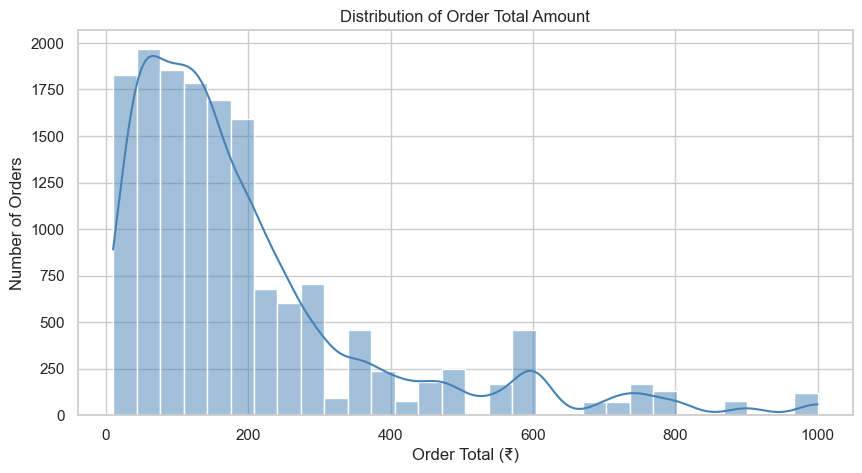

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df['total_amt'], bins=30, color='steelblue', kde=True)
plt.title('Distribution of Order Total Amount')
plt.xlabel('Order Total (₹)')
plt.ylabel('Number of Orders')
plt.savefig('../visuals/revenue_distribution.png', dpi=150)
plt.show()

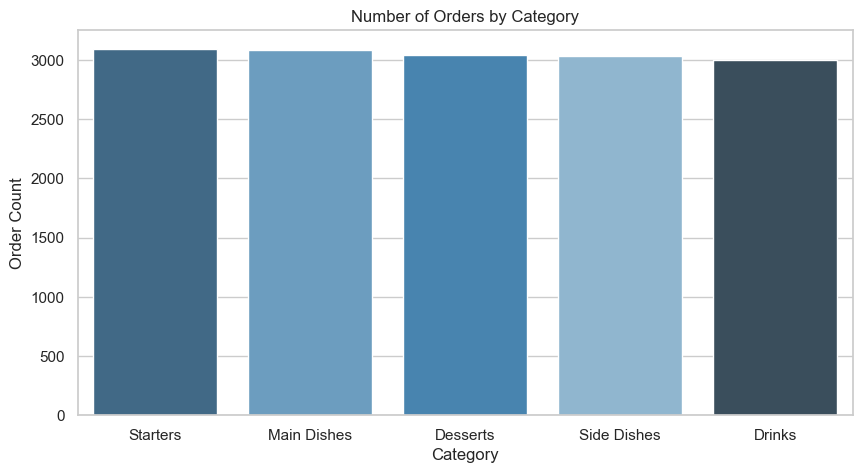

In [4]:
plt.figure(figsize=(10, 5))
order = df['category'].value_counts().index
sns.countplot(
    data=df,
    x='category',
    hue='category',
    order=order,
    palette='Blues_d',
    legend=False
)
plt.title('Number of Orders by Category')
plt.xlabel('Category')
plt.ylabel('Order Count')
plt.savefig('../visuals/category_count.png', dpi=150)
plt.show()

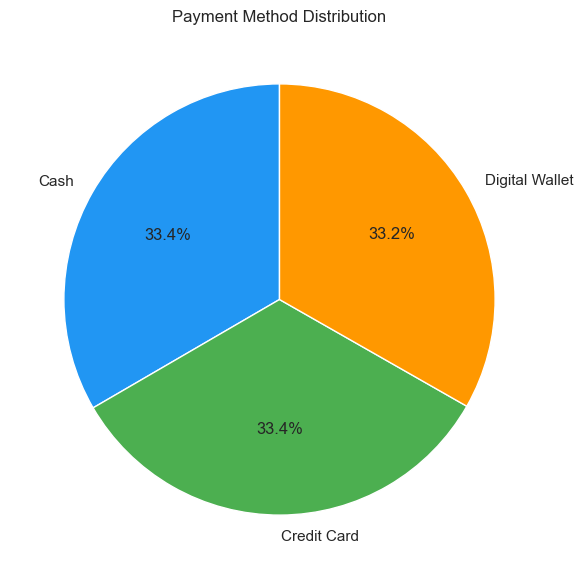

In [4]:
payment_counts = df['payment_method'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%',
        colors=['#2196F3','#4CAF50','#FF9800'], startangle=90)
plt.title('Payment Method Distribution')
plt.savefig('../visuals/payment_pie.png', dpi=150)
plt.show()

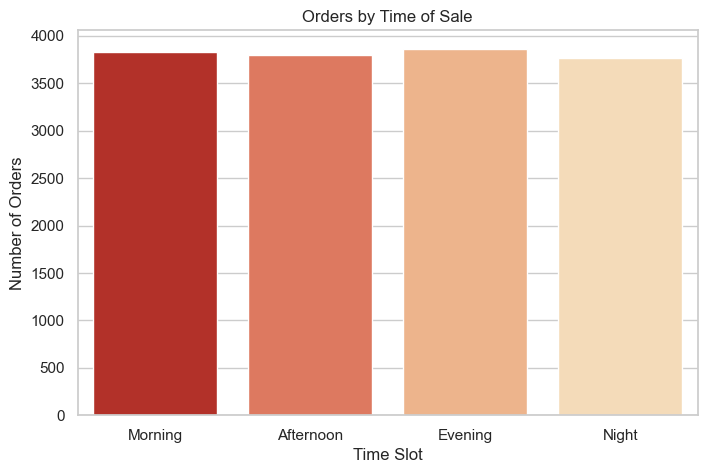

In [5]:
time_order = ['Morning', 'Afternoon', 'Evening', 'Night']

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='time_of_sale',
    hue='time_of_sale',
    order=time_order,
    palette='OrRd',
    legend=False
)

plt.title('Orders by Time of Sale')
plt.xlabel('Time Slot')
plt.ylabel('Number of Orders')

plt.savefig('../visuals/time_of_sale.png', dpi=150)
plt.show()

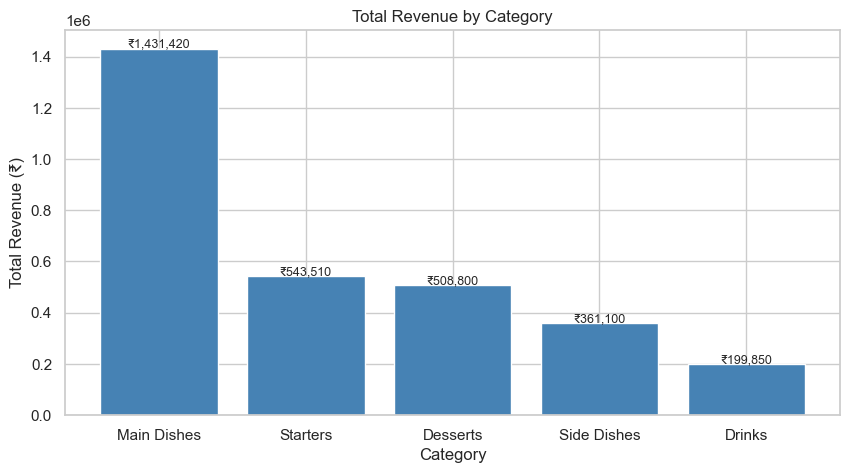

In [6]:
cat_revenue = df.groupby('category')['total_amt'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(cat_revenue['category'], cat_revenue['total_amt'], color='steelblue')
plt.title('Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue (₹)')

# Add value labels on bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f"₹{bar.get_height():,.0f}", ha='center', fontsize=9)

plt.savefig('../visuals/revenue_by_category.png', dpi=150)
plt.show()

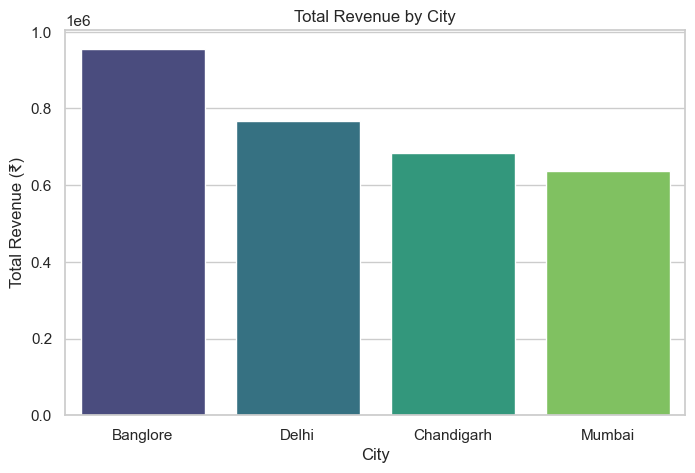

In [6]:
city_rev = (
    df.groupby('city')['total_amt']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=city_rev,
    x='city',
    y='total_amt',
    hue='city',
    palette='viridis',
    legend=False
)

plt.title('Total Revenue by City')
plt.xlabel('City')
plt.ylabel('Total Revenue (₹)')

plt.savefig('../visuals/revenue_by_city.png', dpi=150)
plt.show()

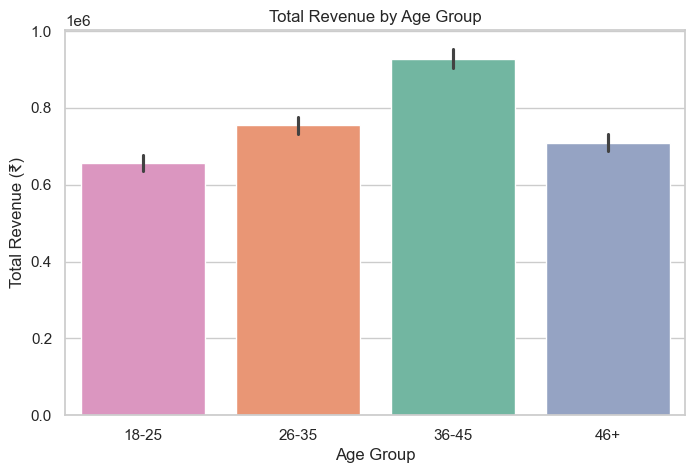

In [8]:
age_order = ['18-25', '26-35', '36-45', '46+']

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='age_group',
    y='total_amt',
    order=age_order,
    estimator=sum,
    hue='age_group',
    palette='Set2',
    legend=False
)

plt.title('Total Revenue by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue (₹)')

plt.savefig('../visuals/revenue_by_age.png', dpi=150)
plt.show()

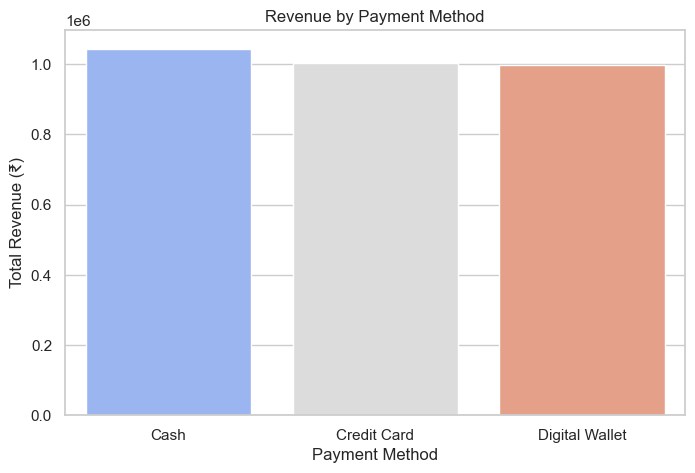

In [9]:
pay_rev = (
    df.groupby('payment_method')['total_amt']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=pay_rev,
    x='payment_method',
    y='total_amt',
    hue='payment_method',
    palette='coolwarm',
    legend=False
)

plt.title('Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Revenue (₹)')

plt.savefig('../visuals/revenue_by_payment.png', dpi=150)
plt.show()

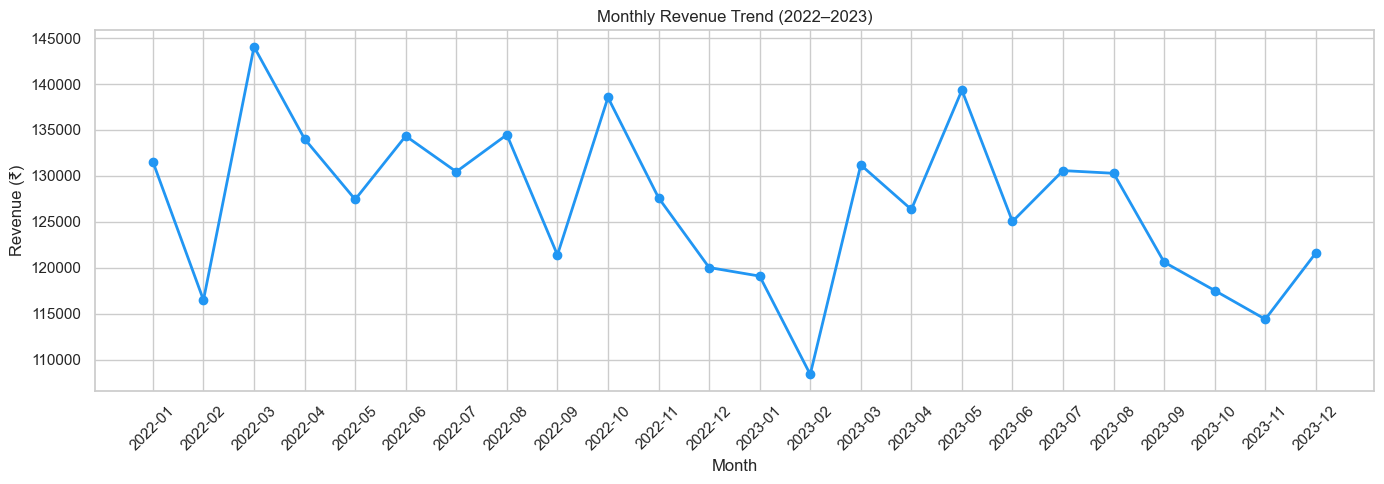

In [10]:
df['year_month'] = df['order_date'].dt.to_period('M')
monthly_rev = df.groupby('year_month')['total_amt'].sum().reset_index()
monthly_rev['year_month_str'] = monthly_rev['year_month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_rev['year_month_str'], monthly_rev['total_amt'], 
         marker='o', linewidth=2, color='#2196F3')
plt.title('Monthly Revenue Trend (2022–2023)')
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/monthly_revenue_trend.png', dpi=150)
plt.show()

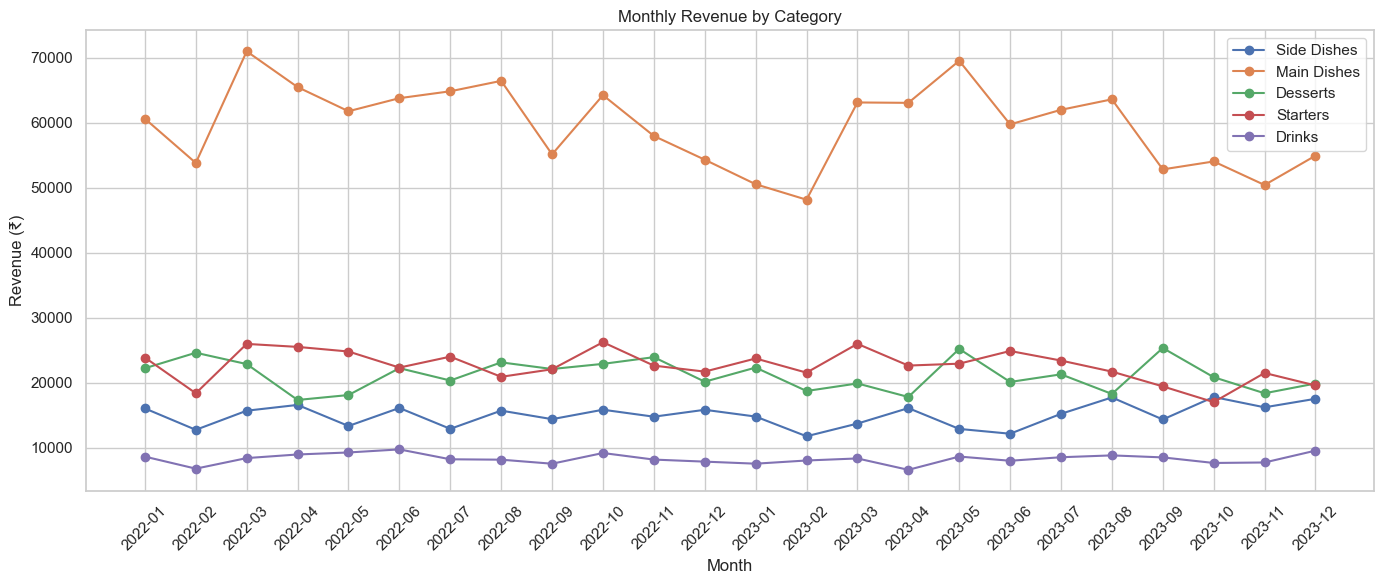

In [11]:
cat_monthly = df.groupby(['year_month', 'category'])['total_amt'].sum().reset_index()
cat_monthly['year_month_str'] = cat_monthly['year_month'].astype(str)

plt.figure(figsize=(14, 6))
for cat in df['category'].unique():
    subset = cat_monthly[cat_monthly['category'] == cat]
    plt.plot(subset['year_month_str'], subset['total_amt'], label=cat, marker='o', linewidth=1.5)

plt.title('Monthly Revenue by Category')
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/category_monthly_trend.png', dpi=150)
plt.show()

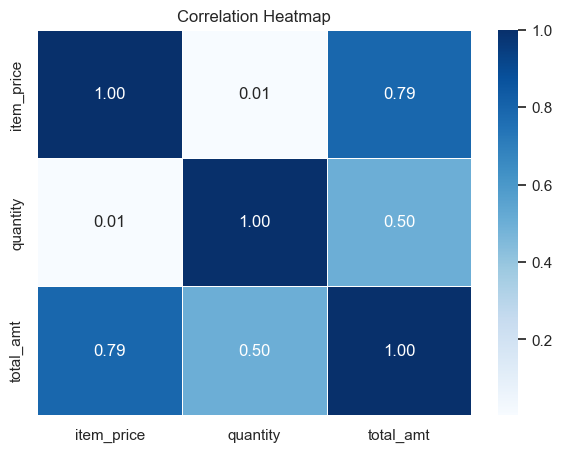

In [12]:
numeric_df = df[['item_price', 'quantity', 'total_amt']]
corr = numeric_df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.savefig('../visuals/correlation_heatmap.png', dpi=150)
plt.show()

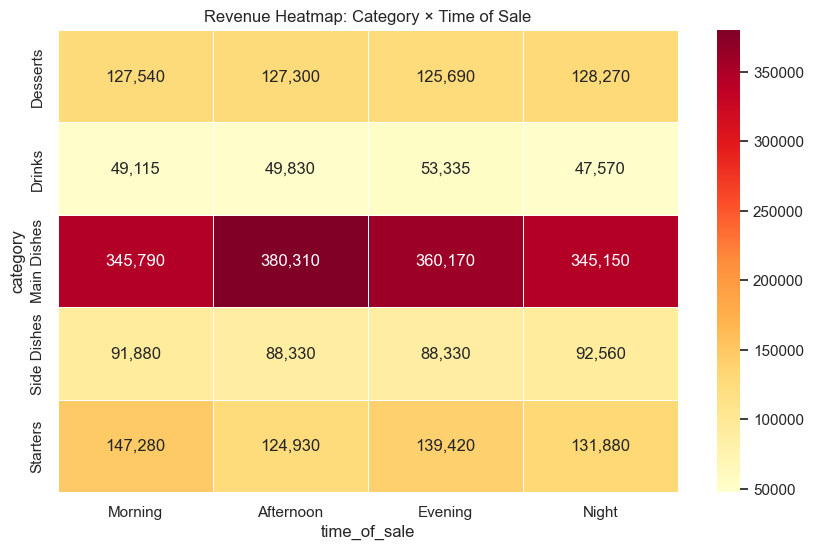

In [13]:
pivot = df.pivot_table(values='total_amt', index='category', 
                       columns='time_of_sale', aggfunc='sum')
pivot = pivot[['Morning', 'Afternoon', 'Evening', 'Night']]

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=',', cmap='YlOrRd', linewidths=0.5)
plt.title('Revenue Heatmap: Category × Time of Sale')
plt.savefig('../visuals/category_time_heatmap.png', dpi=150)
plt.show()